In [1]:
!pip install equinox


[notice] A new release of pip is available: 24.3.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
%matplotlib inline
import matplotlib_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('png')
import seaborn as sns
sns.set_context("paper")
sns.set_style("ticks")
import numpy as np
import jax
import jax.numpy as jnp
import jax.random as jr
from jax.scipy import stats
import equinox as eqx
import optax
from typing import Tuple
from scipy.stats import gaussian_kde
from scipy.ndimage import gaussian_filter
# jax.config.update("jax_enable_x64", True)
colors = sns.color_palette("tab10")
key = jr.PRNGKey(10)

# Amortized Variational Inference

Here, we implement Amortized Variational Inference (AVI) for an inverse kinematics problem. The goal is to infer the configuration of a multi-jointed arm that results in a specific end-effector position (section 3.4 of [Karumuri et al. (2024)](https://www.sciencedirect.com/science/article/am/pii/S0021999124003668)).

### Problem Setup

The forward kinematic model maps the joint configuration $\boldsymbol{\xi} = (\xi_1, \xi_2, \xi_3, \xi_4)^T$ (slider height $\xi_1$ and three joint angles $\xi_2, \xi_3, \xi_4$) to the end-effector's 2D position:

$$\mathbf{f}(\boldsymbol{\xi}) = \begin{pmatrix} f_1(\boldsymbol{\xi}) \\ f_2(\boldsymbol{\xi}) \end{pmatrix} = \begin{pmatrix} l_1 \cos(\xi_2) + l_2 \cos(\xi_2 + \xi_3) + l_3 \cos(\xi_2 + \xi_3 + \xi_4) \\ \xi_1 + l_1 \sin(\xi_2) + l_2 \sin(\xi_2 + \xi_3) + l_3 \sin(\xi_2 + \xi_3 + \xi_4) \end{pmatrix}$$

where arm lengths $l_1 = 0.5$, $l_2 = 0.5$, and $l_3 = 1.0$. We observe a noisy version of the end-effector position, contaminated with a Gaussian distribution as:

$$\mathbf{y} \sim \mathcal{N}(\mathbf{f}(\boldsymbol{\xi}), \gamma^2 \mathbf{I}) = \mathcal{N}\left(\mathbf{f}(\boldsymbol{\xi}), 
\begin{pmatrix}
1 \times 10^{-4} & 0 \\
0 & 1 \times 10^{-4}
\end{pmatrix}\right)$$

where $\gamma^2 = 1 \times 10^{-4}$ is the observation noise variance (assumed to be known).

<p align="center">
  <img src="https://raw.githubusercontent.com/PredictiveScienceLab/advanced-scientific-machine-learning/refs/heads/main/book/images/kinematic_system_view.png" alt="System schematic" width="300"/>
</p>


In [3]:
# System constants
xi_dim = 4 
y_dim = 2
noise_scale = jnp.array([0.01, 0.01])
lens = jnp.array([0.5, 0.5, 1.0]) # lengths of the kinematic links


In [4]:
# Forward kinematics utility functions
# Location of the end points of the links
def segment_points(p_, length, angle):
    """
    Determine location (x2, y2) of link based on (x1, y1), length, and angle.

    Parameters:
        p_ (array): Starting points of the segment, shape (N, 2)
        length (float): Length of the segment
        angle (array or float): Angle(s) in radians

    Returns:
        tuple: (p_, p) where p_ is the original points, 
               and p is the computed end points after applying the length and angle
    """
    p = jnp.zeros(p_.shape)
    p = p.at[:, 0].set(p_[:, 0] + length * jnp.cos(angle))
    p = p.at[:, 1].set(p_[:, 1] + length * jnp.sin(angle))
    return p_, p

# Forward kinematics model
def forward_process(xi):
    """
    Implements the forward process f(xi) and 
    and returns each of the arm’s end points as dictionary.
    """
    values = dict()
    xi = xi.reshape(-1, 4)
    A = jnp.stack([jnp.zeros((xi.shape[0])), xi[:, 0]], axis=1)
    _, B = segment_points(A, lens[0], xi[:, 1])
    _, C = segment_points(B, lens[1], xi[:, 1] + xi[:, 2])
    _, D = segment_points(C, lens[2], xi[:, 1] + xi[:, 2] + xi[:, 3])
    values['A'] = A
    values['B'] = B
    values['C'] = C
    values['D'] = D
    return values

# # Test forward kinematics
# test_xi = jnp.array([[0.1, jnp.pi/12, jnp.pi/6, jnp.pi/6]])
# RESULT = forward_process(test_xi)
# print("Test forward kinematics:", RESULT)
# print("A:", RESULT['A'][0])
# print("B:", RESULT['B'][0])
# print("C:", RESULT['C'][0])
# print("D:", RESULT['D'][0])

### Prior Definition

To set up our inference, we assume a Gaussian prior for our parameters:

$$\boldsymbol{\xi} \sim \mathcal{N}(\mathbf{0}, \text{diag}(\boldsymbol{\sigma}^2)) = \mathcal{N}\left(\mathbf{0}, \begin{pmatrix} \frac{1}{16} & 0 & 0 & 0 \\ 0 & \frac{1}{4} & 0 & 0 \\ 0 & 0 & \frac{1}{4} & 0 \\ 0 & 0 & 0 & \frac{1}{4} \end{pmatrix}\right)$$

In [5]:
# Prior distribution
prior_loc = jnp.zeros(xi_dim)
prior_scale = jnp.array([0.25, 0.5, 0.5, 0.5]) 
prior_xi_dist = {'loc': prior_loc, 'scale': prior_scale}

In [6]:
def sample_prior(prior_xi_dist, key, n, xi_dim):
    """Sample from the prior distribution."""
    # Handle both tuples (from static fields) and arrays
    prior_loc = jnp.array(prior_xi_dist['loc'])[:xi_dim]
    prior_scale = jnp.array(prior_xi_dist['scale'])[:xi_dim]
    return prior_loc[None, :] + prior_scale[None, :] * jr.normal(key, (n, xi_dim))


Let's see how the trajectories reconstructed by this prior look like.

In [7]:
def plot_prior(xi_samples, lens):
    fig = plt.figure(figsize=(6, 4))
    axarr = fig.add_subplot(1,1,1)

    # Forward kinematics to get positions of the links
    result = forward_process(jnp.array(xi_samples))
    xi0 = np.array(result['A'])
    xi1 = np.array(result['B'])
    xi2 = np.array(result['C'])
    xi3 = np.array(result['D'])
    plt.axvline(x=0, ls=':', linewidth=.75, color='gray')
    
    # Plot prior sample trajectories and links
    opts_prior = {'alpha':0.01, 'scale':1, 'angles':'xy', 'scale_units':'xy',
                    'headlength':0, 'headaxislength':0, 'linewidth':1.0, 'rasterized':True}
    prior_legend_line = Line2D([0], [0], color=colors[0], linewidth=1.0, label='Prior samples')
    plt.quiver(xi0[:,0], xi0[:,1], (xi1-xi0)[:,0], (xi1-xi0)[:,1], color=colors[0], **opts_prior)
    plt.quiver(xi1[:,0], xi1[:,1], (xi2-xi1)[:,0], (xi2-xi1)[:,1], color=colors[0], **opts_prior)
    plt.quiver(xi2[:,0], xi2[:,1], (xi3-xi2)[:,0], (xi3-xi2)[:,1], color=colors[0], **opts_prior)
    
    # Plot a sample from prior as the highlighted trajectory
    prior_sample = xi_samples[0:1]  # (1, xi_dim)
    result_sample = forward_process(jnp.array(prior_sample))
    A = np.array(result_sample['A'])
    B = np.array(result_sample['B'])
    C = np.array(result_sample['C'])
    D = np.array(result_sample['D'])

    sample_line = plt.plot(
        [A[0, 0], B[0, 0], C[0, 0]],
        [A[0, 1], B[0, 1], C[0, 1]],
        '-', linewidth=1, color=colors[2], zorder=4, label='A sample of prior'
    )[0]

    plt.arrow(
        C[0, 0], C[0, 1],
        D[0, 0] - C[0, 0], D[0, 1] - C[0, 1],
        linewidth=1,
        head_width=0.05,
        head_length=0.04,
        overhang=0.1,
        length_includes_head=True,
        color=colors[2],
        zorder=4
    )

    plt.scatter(
        [A[0, 0]], [A[0, 1]],
        s=100, marker='s', linewidth=1,
        facecolors='white', edgecolors=colors[2], zorder=3
    )

    plt.scatter(
        [A[0, 0], B[0, 0], C[0, 0]],
        [A[0, 1], B[0, 1], C[0, 1]],
        s=10, marker='o', linewidth=1,
        facecolors='white', edgecolors=colors[2], zorder=5
    )
    
    # Plotted range
    rangex = (-0.35, 2.25)
    rangey = (-1.3, 1.3)

    plt.xlim(rangex)
    plt.ylim(rangey)
    plt.xlabel('')
    plt.ylabel('')
    plt.legend(handles=[prior_legend_line, sample_line], loc='best')
    plt.show()


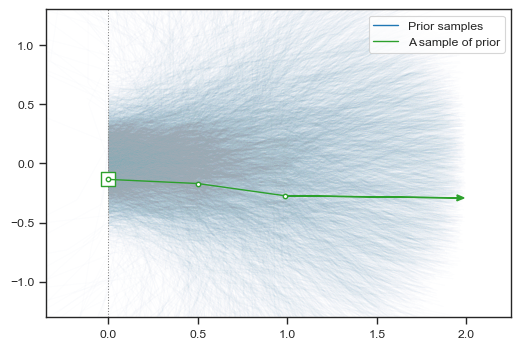

In [8]:
# Plot of reconstructed trajectories by the prior
n_samples = 5000 # number of reconstructed samples
Prior_data = sample_prior(prior_xi_dist, key, n_samples, xi_dim)
plot_prior(Prior_data, lens)

In Amortized Variational Inference (AVI), we use these samples from the prior as our training data. They allow us to learn the map from observed data to the corresponding posterior distribution, which is called the inference function.

### Guide Setup
For our guide, we use a full-rank multivariate Gaussian: $q_{\phi}(\xi|y) = \mathcal{N}(\xi \mid \mu_\phi (y), \Sigma_\phi (y))$, where both the mean $\mu_\phi$ and covariance $\Sigma_\phi$ are parameterized. To ensure $\Sigma_\phi$ is positive definite, we represent it via its lower-triangular Cholesky factor $L_\phi$, where $\Sigma_\phi = LL^\top$. See <a href="https://predictivesciencelab.github.io/advanced-scientific-machine-learning/inverse/vi/01_basics.html" target="_blank">lecture notes</a> for details.

In [9]:
def unpack_cholesky(L_diag, L_offdiag, xi_dim):
    """
    Constructs Cholesky L matrix from diagonal and off-diagonal elements.
    
    Args:
        L_diag: Diagonal elements (xi_dim,)
        L_offdiag: Off-diagonal elements (xi_dim*(xi_dim-1)/2,)
        xi_dim: Dimension of the latent space
    
    Returns:
        Lower triangular Cholesky matrix (xi_dim, xi_dim)
    """
    chol_diag = jnp.diag(L_diag)
    chol_offdiag = jnp.zeros((xi_dim, xi_dim))
    tril_indices = jnp.tril_indices(xi_dim, k=-1)
    chol_offdiag = chol_offdiag.at[tril_indices].set(L_offdiag)
    
    q_L = chol_diag + chol_offdiag
    return q_L


### Inference Function Setup

We assume the inference function, which is the map from the observational data $y$ to the posterior parameters $(\mu_\phi (y), L_\phi (y))$, can be approximated through neural networks. Here is how we specify the inference configurations in AVI:

In [10]:
class Amortized_VI(eqx.Module):
    """
    Amortized Variational Inference network for Bayesian inverse problems.
    
    Args:
        key: Random key for network initialization
        xi_dim: Dimension of latent variable ξ
        y_dim: Dimension of observation y
        prior_xi_dist: Prior distribution dict with keys "loc" and "scale"
        f: Forward model function
        noise_scale: Observation noise std
    
    Attributes:
        mu: Network outputting posterior mean μ(y)
        L_diag: Network outputting diagonal of Cholesky factor L
        L_offdiag: Network outputting off-diagonal elements of Cholesky factor L
    """
    xi_dim: int = eqx.field(static=True)
    y_dim: int = eqx.field(static=True)
    prior_xi_dist: dict
    f: callable = eqx.field(static=True)
    noise_scale: Tuple[float, ...]
    mu: eqx.nn.Sequential
    L_diag: eqx.nn.Sequential
    L_offdiag: eqx.nn.Sequential

    def __init__(self, key, xi_dim=4, y_dim=2,
                prior_xi_dist=None, f=forward_process, noise_scale=None):
        """
        Initialize the amortized VI network.
        
        Creates three separate neural networks for mu, L_diag, and L_offdiag
        """
        keys = jr.split(key, 9)
        self.xi_dim = xi_dim
        self.y_dim = y_dim
        self.f = f
        self.noise_scale = tuple(np.array(noise_scale))
        self.prior_xi_dist = {
            "loc": np.asarray(prior_xi_dist["loc"], dtype=float),
            "scale": np.asarray(prior_xi_dist["scale"], dtype=float),
        }
        
        self.mu = eqx.nn.Sequential([
            eqx.nn.Linear(self.y_dim, 20, key=keys[0]),
            eqx.nn.Lambda(jax.nn.relu),
            eqx.nn.Linear(20, 10, key=keys[1]),
            eqx.nn.Lambda(jax.nn.relu),
            eqx.nn.Linear(10, self.xi_dim, key=keys[2])
        ])
        
        self.L_diag = eqx.nn.Sequential([
            eqx.nn.Linear(self.y_dim, 20, key=keys[3]),
            eqx.nn.Lambda(jax.nn.relu),
            eqx.nn.Linear(20, 10, key=keys[4]),
            eqx.nn.Lambda(jax.nn.relu),
            eqx.nn.Linear(10, self.xi_dim, key=keys[5]),
            eqx.nn.Lambda(lambda x: jax.nn.softplus(x) + 1e-6)  # Ensure positiveness
        ])
        
        n_offdiag = int(self.xi_dim * (self.xi_dim - 1) / 2)
        self.L_offdiag = eqx.nn.Sequential([
            eqx.nn.Linear(self.y_dim, 20, key=keys[6]),
            eqx.nn.Lambda(jax.nn.relu),
            eqx.nn.Linear(20, 10, key=keys[7]),
            eqx.nn.Lambda(jax.nn.relu),
            eqx.nn.Linear(10, n_offdiag, key=keys[8]),
        ])
        
    def observed_data(self, key, n=30):
        """
        Generate synthetic training data by sampling from prior and adding noise.
        """
        key1, key2 = jr.split(key, 2)
        
        # Sample joint configurations from prior
        xi_data = sample_prior(self.prior_xi_dist, key1, n, self.xi_dim)
        # Generate noisy observations from the prior sample
        y_true = self.f(xi_data)['D']
        noise = jnp.array(self.noise_scale) * jr.normal(key2, y_true.shape)
        y_data = y_true + noise
        
        return xi_data, y_data

    def forward(self, key, num_particles=2, num_training_obs=32):
        """
        Compute ELBO over all the training observations.
        """
        key1, key2 = jr.split(key, 2)
        
        # Generate batch of training data
        _, y = self.observed_data(key1, n=num_training_obs)

        # Infer posterior parameters for all observations in batch
        q_mu = jax.vmap(self.mu)(y)
        q_L_diag = jax.vmap(self.L_diag)(y)
        q_L_offdiag = jax.vmap(self.L_offdiag)(y)

        # Construct full Cholesky matrices L for each observation
        q_L_all = jax.vmap(unpack_cholesky, in_axes=(0, 0, None))(
            q_L_diag, q_L_offdiag, self.xi_dim
        )
        
        def compute_elbo_for_data_point(q_mu_j, q_Lj, y_j, key_j):
            """
            Compute ELBO for a single data point y_j.
            """
            # Sample standard normal variables for reparameterization trick
            particle_keys = jr.split(key_j, num_particles)
            zs = jax.vmap(lambda k: jr.normal(k, (self.xi_dim,)))(particle_keys)
            
            # Reparameterization trick
            xi_samples = q_mu_j[None, :] + zs @ q_Lj.T
            
            # Compute log prior
            prior_loc = self.prior_xi_dist['loc'][:self.xi_dim]
            prior_scale = self.prior_xi_dist['scale'][:self.xi_dim]
            log_prior = jnp.sum(
                stats.norm.logpdf(xi_samples, loc=prior_loc, scale=prior_scale),
                axis=1
            )
            
            # Compute log likelihood
            y_pred = self.f(xi_samples)['D']
            log_likelihood = jnp.sum(
                stats.norm.logpdf(
                    y_j[None, :],
                    loc=y_pred,
                    scale=jnp.array(self.noise_scale)
                ),
                axis=1)
            
            # Average over Monte Carlo samples
            datafit = jnp.mean(log_prior + log_likelihood)
            
            # Entropy term: 0.5 * log(det(2*pi*e*L@L.T))
            diag_Lj = jnp.diag(q_Lj)
            log_det = 2.0 * jnp.sum(jnp.log(jnp.maximum(diag_Lj, 1e-9)))
            entropy = 0.5 * (self.xi_dim * (1.0 + jnp.log(2.0 * jnp.pi)) + log_det)
            
            return datafit + entropy

        # Compute ELBO for each observation in the batch
        n_obs = y.shape[0]
        data_keys = jr.split(key2, n_obs)
        elbos = jax.vmap(compute_elbo_for_data_point)(
            q_mu, q_L_all, y, data_keys
        )
        
        # Return mean ELBO over batch
        return jnp.mean(elbos)

    def __call__(self, key, num_particles=2, num_training_obs=30):
        return self.forward(key,
                            num_particles=num_particles,
                            num_training_obs=num_training_obs)

In [11]:
init_key, train_key = jr.split(key, 2)
model = Amortized_VI(
    key=init_key,
    xi_dim=xi_dim,
    y_dim=y_dim,
    prior_xi_dist=prior_xi_dist,
    f=forward_process,
    noise_scale=noise_scale,
)

To train the amortized VI model, we need to define the loss function and the optimizer settings. We do that as follows:

In [12]:
def train_amortized_vi(model, key, n_steps=10000, num_particles=5):
    """
    Train the amortized variational inference model.
    
    Args:
        model: Amortized_VI instance
        key: Random key
        n_steps: Number of training steps
        num_particles: Number of Monte Carlo samples for ELBO estimation
    
    Returns:
        model: Trained Amortized_VI instance.
        history: Dictionary containing training history with keys:
            - 'steps': List of step numbers
            - 'losses': List of loss values (negative ELBO)
            - 'learning_rates': List of learning rates at each step
    """
    # Learning rate schedule
    learning_rate = optax.piecewise_constant_schedule(
        init_value=0.01, 
        boundaries_and_scales={5000: 0.1}  # Multiply by 0.1 at step 5000
    )
    
    # Initialize Adam optimizer
    optim = optax.adam(learning_rate)

    @eqx.filter_jit
    def compute_loss_and_grads(model, key):
        """
        Compute negative ELBO and gradients.
        """
        loss, grads = eqx.filter_value_and_grad(
            lambda m: -m(key, num_particles=num_particles)
        )(model)
        return loss, grads

    def update_step(model, opt_state, grads):
        """
        Apply one optimization step using Adam.
        """
        updates, opt_state = optim.update(grads, opt_state)
        model = eqx.apply_updates(model, updates)
        return model, opt_state

    # Initialize optimizer state
    init_key, train_key = jr.split(key)
    _, initial_grads = compute_loss_and_grads(model, init_key)

    # Exclude prior_xi_dist and noise_scale from training (fixed hyperparameters)
    initial_grads = eqx.tree_at(lambda x: x.prior_xi_dist, initial_grads, None)
    initial_grads = eqx.tree_at(lambda x: x.noise_scale, initial_grads, None)
    learnable_grads = eqx.filter(initial_grads, eqx.is_array)
    opt_state = optim.init(learnable_grads)

    # Initialize training history to track progress
    history = {'steps': [], 'losses': [], 'learning_rates': []}
    
    # Main training loop
    for step in range(n_steps):
        train_key, step_key = jr.split(train_key)
        
        # Compute loss and update
        loss, grads = compute_loss_and_grads(model, step_key)
        
        # Exclude prior_xi_dist and noise_scale from training
        grads = eqx.tree_at(lambda x: x.prior_xi_dist, grads, None)
        grads = eqx.tree_at(lambda x: x.noise_scale, grads, None)
        learnable_grads = eqx.filter(grads, eqx.is_array)
        model, opt_state = update_step(model, opt_state, learnable_grads)
        current_lr = learning_rate(step)

        # Record training history
        history['steps'].append(step)
        history['losses'].append(float(loss))
        history['learning_rates'].append(float(current_lr))
        
        # Print
        if step % 500 == 0: 
            print(f'Step {step}: loss = {loss:.2f}, lr = {current_lr:.5f}')
    
    return model, history

### AVI Train

In [13]:
model, history = train_amortized_vi(
    model,
    train_key,
    n_steps=10000,
    num_particles=6,
)


Step 0: loss = 25340.73, lr = 0.01000
Step 500: loss = 105.11, lr = 0.01000
Step 1000: loss = 22.33, lr = 0.01000
Step 1500: loss = 13.39, lr = 0.01000
Step 2000: loss = 20.12, lr = 0.01000
Step 2500: loss = 56.91, lr = 0.01000
Step 3000: loss = 45.04, lr = 0.01000
Step 3500: loss = 11.53, lr = 0.01000
Step 4000: loss = 11.53, lr = 0.01000
Step 4500: loss = 7.66, lr = 0.01000
Step 5000: loss = 20.21, lr = 0.00100
Step 5500: loss = 14.86, lr = 0.00100
Step 6000: loss = 7.57, lr = 0.00100
Step 6500: loss = 12.79, lr = 0.00100
Step 7000: loss = 5.72, lr = 0.00100
Step 7500: loss = 4.61, lr = 0.00100
Step 8000: loss = 7.09, lr = 0.00100
Step 8500: loss = 7.26, lr = 0.00100
Step 9000: loss = 3.81, lr = 0.00100
Step 9500: loss = 4.87, lr = 0.00100


Here is the trend of the loss (-ELBO):

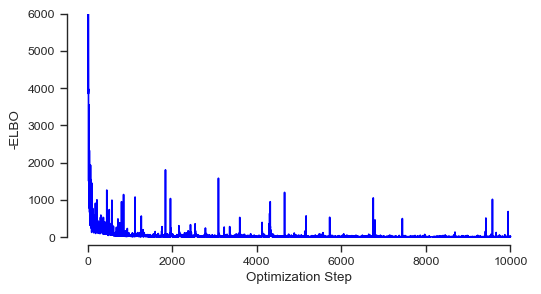

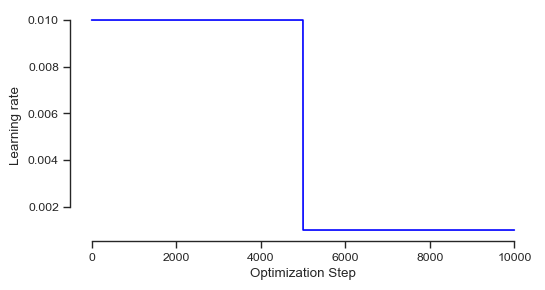

In [14]:
# Plot the loss and learning rate        
fig, ax = plt.subplots(figsize=(6, 3))
ax.plot(history['steps'], history['losses'], 'b')
ax.set_ylim(-200, 6000)
ax.set_xlabel('Optimization Step')
ax.set_ylabel('-ELBO')
sns.despine(ax=ax, trim=True)
plt.show()

fig, ax = plt.subplots(figsize=(6, 3))
ax.plot(history['steps'], history['learning_rates'], 'b')
ax.set_xlabel('Optimization Step')
ax.set_ylabel('Learning rate')
sns.despine(ax=ax, trim=True)
plt.show();

### Evaluating the Trained Model

After training, we want to examine how well our amortized inference network performs the inference on a few target systems with known ground truth for the joint configurations.

In [15]:
def draw_isolines(samples, filter_width):
    """
    Draw probability density isolines for end-effector positions.
    
    Args:
        samples: Joint configuration samples
        filter_width: Gaussian filter width for smoothing
    """
    if not filter_width > 0:
        return

    # Forward kinematics
    result = forward_process(jnp.array(samples))
    y = np.array(result['D'])
    
    valid_mask = np.isfinite(y[:, 0]) & np.isfinite(y[:, 1])
    if not np.any(valid_mask):
        return

    # Define plotting range
    rangex = (-0.35, 2.25)
    rangey = (-2.0, 1.3)

    # Compute 2D histogram of end-effector positions
    hist, xbins, ybins = np.histogram2d(
        y[:, 0], y[:, 1], 
        bins=600, 
        range=[rangex, rangey], 
        density=True
    )

    # Smooth histogram with Gaussian filter
    hist = gaussian_filter(hist, filter_width)

    # Find threshold for 3% probability mass
    percentile = 0.03 * np.sum(hist)
    for q in np.logspace(-99, np.log10(np.max(hist)), 8000, endpoint=True):
        if np.sum(hist[hist < q]) > percentile: break
    else:
        q = 1.0

    # Create meshgrid for contour plot
    X, Y = np.meshgrid(
        0.5 * (xbins[:-1] + xbins[1:]),
        0.5 * (ybins[:-1] + ybins[1:])
    )

    # Draw contour line
    plt.contour(X, Y, hist.T, [q], linewidths=0.7, zorder=3, colors=[colors[1]])


def plot_reconstructed(xi_samples, xi_data, y_data, lens, filter_width=4.0, arrows=False):
    """
    Plot reconstructed trajectories from AVI samples and ground truth.
    
    Args:
        xi_samples: Posterior samples from AVI
        xi_data: Ground truth joint configuration
        y_data: Observed end-effector position
        lens: Link lengths
        filter_width: Gaussian filter width for isolines
        arrows: Whether to show arrows (unused, kept for compatibility)
    """
    fig = plt.figure(figsize=(5, 3))
    axarr = fig.add_subplot(1, 1, 1)
    
    lens = np.array(lens)
    xi = np.array(xi_samples)
    y_target = y_data[0]
    
    # Forward kinematics for AVI samples
    result = forward_process(jnp.array(xi))
    xi0 = np.array(result['A'])
    xi1 = np.array(result['B'])
    xi2 = np.array(result['C'])
    xi3 = np.array(result['D'])

    # Draw reference lines
    plt.axvline(x=0, ls=':', linewidth=0.75, color='gray')
    if not arrows:
        # Draw crosshair at target position
        l_cross = 0.6
        plt.plot(
            [y_target[0] - l_cross, y_target[0] + l_cross], 
            [y_target[1], y_target[1]], 
            ls=':', linewidth=0.75, color='gray', alpha=0.5, zorder=-1
        )
        plt.plot(
            [y_target[0], y_target[0]], 
            [y_target[1] - l_cross, y_target[1] + l_cross], 
            ls=':', linewidth=0.75, color='gray', alpha=0.5, zorder=-1
        )
    
    # Plot AVI sample trajectories (many transparent links)
    opts_avi = {
        'alpha': 0.02, 'scale': 1, 'angles': 'xy', 'scale_units': 'xy',
        'headlength': 0, 'headaxislength': 0, 'linewidth': 1.0, 'rasterized': True
    }
    avi_legend_line = Line2D([0], [0], color=colors[1], linewidth=1.0, label='AVI samples')
    plt.quiver(xi0[:, 0], xi0[:, 1], (xi1 - xi0)[:, 0], (xi1 - xi0)[:, 1], 
               color=colors[1], **opts_avi)
    plt.quiver(xi1[:, 0], xi1[:, 1], (xi2 - xi1)[:, 0], (xi2 - xi1)[:, 1], 
               color=colors[1], **opts_avi)
    plt.quiver(xi2[:, 0], xi2[:, 1], (xi3 - xi2)[:, 0], (xi3 - xi2)[:, 1], 
               color=colors[1], **opts_avi)
    
    # Plot ground truth trajectory
    result_sample = forward_process(jnp.array(xi_data))
    A = np.array(result_sample['A'])
    B = np.array(result_sample['B'])
    C = np.array(result_sample['C'])
    D = np.array(result_sample['D'])
    
    # Draw ground truth links
    gt_line = plt.plot(
        [A[0, 0], B[0, 0], C[0, 0]],
        [A[0, 1], B[0, 1], C[0, 1]],
        '-', linewidth=1, color=colors[2], zorder=4, label='Ground truth'
    )[0]
    
    # Draw final link as arrow
    plt.arrow(
        C[0, 0], C[0, 1],
        D[0, 0] - C[0, 0], D[0, 1] - C[0, 1],
        linewidth=1, head_width=0.05, head_length=0.04, overhang=0.1,
        length_includes_head=True, color=colors[2], zorder=4
    )
    
    # Mark base joints
    plt.scatter(
        [A[0, 0]], [A[0, 1]],
        s=100, marker='s', linewidth=1,
        facecolors='white', edgecolors=colors[2], zorder=3
    )
    plt.scatter(
        [A[0, 0], B[0, 0], C[0, 0]],
        [A[0, 1], B[0, 1], C[0, 1]],
        s=10, linewidth=1,
        facecolors='white', edgecolors=colors[2], zorder=5
    )

    # Draw probability density isolines
    draw_isolines(xi, filter_width)
    
    plt.xlabel('')
    plt.ylabel('')
    plt.legend(handles=[avi_legend_line, gt_line], loc='best')
    plt.show()




In [16]:
def pair_plot(prior_samples, avi_samples, xi_data):
    """
    Create pair plot comparing prior and AVI posterior distributions.
    
    Args:
        prior_samples: Array of shape (xi_dim, n_samples) - each row is a dimension
        avi_samples: Array of shape (xi_dim, n_samples) - each row is a dimension
        xi_data: Array of shape (1, xi_dim) - ground truth values
    """
    # Filter out NaN and inf values
    prior_samples = np.where(np.isfinite(prior_samples), prior_samples, np.nan)
    avi_samples = np.where(np.isfinite(avi_samples), avi_samples, np.nan)
    
    xi_dim = prior_samples.shape[0]
    column_labels = [r'$\xi_{%.0f}$' % (i + 1) for i in range(xi_dim)]
    fig, axes = plt.subplots(
        xi_dim, xi_dim, 
        figsize=(9, 6), 
        sharex="col", 
        constrained_layout=True
    )
    
    # Fill each subplot
    for i in range(xi_dim):
        for k in range(xi_dim):
            # lower-triangle
            if i > k:
                axes[i, k].scatter(
                    prior_samples[k], prior_samples[i], 
                    s=10, alpha=0.5, label='Prior', color=colors[0]
                )
                axes[i, k].scatter(
                    avi_samples[k], avi_samples[i], 
                    s=10, alpha=0.5, label='AVI', color=colors[1]
                )
                axes[i, k].set_xlabel(None)
                axes[i, k].set_ylabel(None)

            # main diagonal
            if i == k:
                # Plot prior KDE
                if len(prior_samples[k]) > 1:
                    kde_prior = gaussian_kde(prior_samples[k])
                    x_prior = np.linspace(
                        prior_samples[k].min(), 
                        prior_samples[k].max(), 
                        200
                    )
                    axes[i, k].plot(
                        x_prior, kde_prior(x_prior), 
                        label='Prior', color=colors[0]
                    )
                
                # Plot AVI KDE
                if len(avi_samples[k]) > 1:
                    kde_avi = gaussian_kde(avi_samples[k])
                    x_avi = np.linspace(
                        avi_samples[k].min(), 
                        avi_samples[k].max(), 
                        200
                    )
                    axes[i, k].plot(
                        x_avi, kde_avi(x_avi), 
                        label='AVI', color=colors[1]
                    )
                
                # Ground truth
                axes[i, k].axvline(x=xi_data[0][k], color='black', ls='--')
                axes[i, k].set_ylim(bottom=0)
                axes[i, k].set_xlabel(None)
                axes[i, k].set_ylabel(None)

                if k == 0:
                    axes[i, k].legend(loc='upper right', title=None, frameon=True)
                else:
                    axes[i, k].legend([], [], frameon=False)

            # upper triangle
            if i < k:
                axes[i, k].remove()
                     
    for i, col in enumerate(column_labels):
        axes[i, 0].set_ylabel(col)
        axes[-1, i].set_xlabel(col)
    plt.show()


Let's take a look at the AVI posterior distribution and reconstructed configuration for 5 different cases. Note that once the AVI is trained, the inference step runs on-the-fly.

------------------------------------------------------------
Groundtruth for Case 1:
 xi_data=[-0.05219902 -0.06371359 -1.0355055   0.07204475],
 y_data=[ 1.2536975 -1.3746817]
Estimated mean:
[ 0.0121984  -0.24801934 -0.6257988  -0.20514658]
Estimated covariance matrix:
[[ 0.00239224 -0.00535744  0.00530251  0.00076718]
 [-0.00535744  0.01372041 -0.01639394  0.00179888]
 [ 0.00530251 -0.01639394  0.03164258 -0.01951282]
 [ 0.00076718  0.00179888 -0.01951282  0.02541864]]


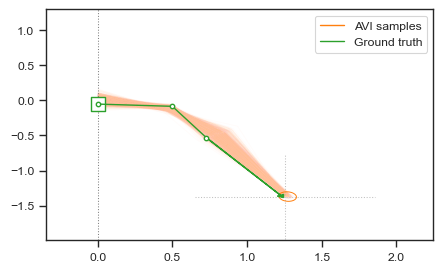

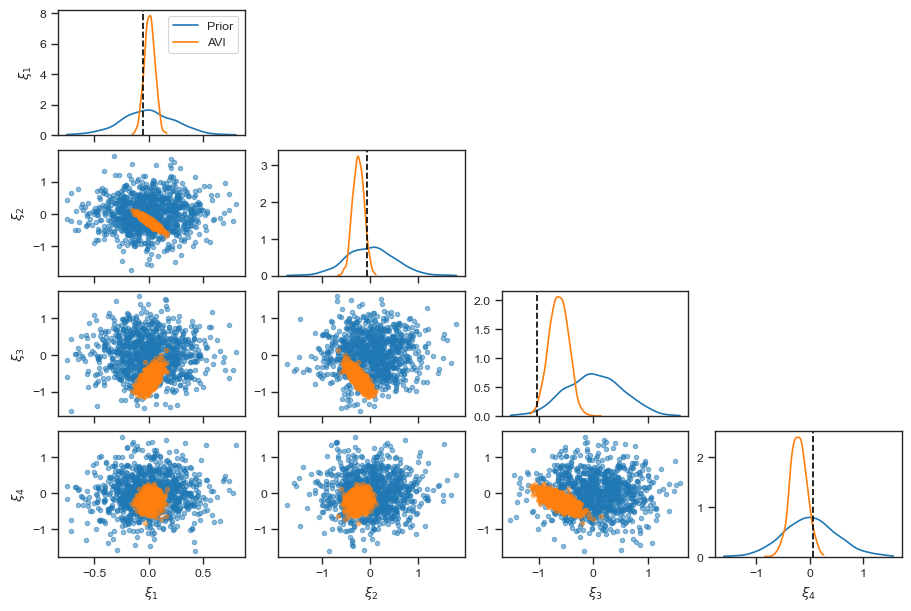

------------------------------------------------------------
Groundtruth for Case 2:
 xi_data=[-0.27141687 -0.20784056 -0.27986643  0.07308158],
 y_data=[ 1.857035 -1.022977]
Estimated mean:
[-0.35192174 -0.10618507 -0.337586    0.03270662]
Estimated covariance matrix:
[[ 0.00216245 -0.00509364  0.00504141  0.0007294 ]
 [-0.00509364  0.01357893 -0.01620436  0.00165134]
 [ 0.00504141 -0.01620436  0.03163406 -0.01950646]
 [ 0.0007294   0.00165134 -0.01950646  0.02540747]]


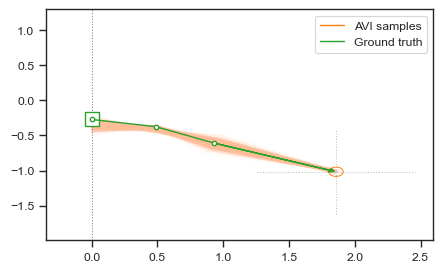

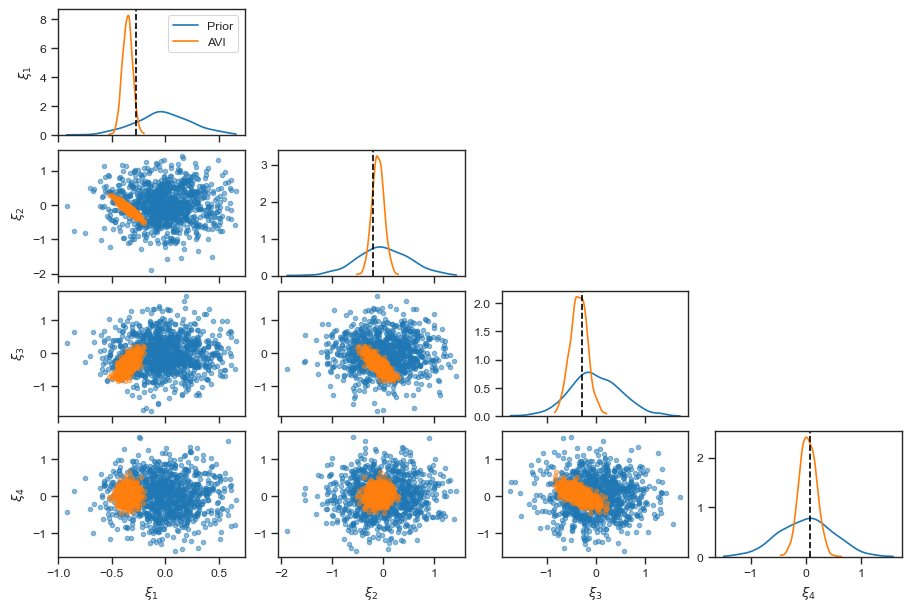

------------------------------------------------------------
Groundtruth for Case 3:
 xi_data=[-0.26510853  0.3257717  -0.18430793  0.83962744],
 y_data=[1.536511  0.7921257]
Estimated mean:
[-0.3416744   0.08459292  0.59906906  0.19457586]
Estimated covariance matrix:
[[ 0.00229975 -0.00525286  0.005199    0.0007522 ]
 [-0.00525286  0.01367035 -0.01632778  0.0017474 ]
 [ 0.005199   -0.01632778  0.03178827 -0.01962102]
 [ 0.0007522   0.0017474  -0.01962102  0.02541493]]


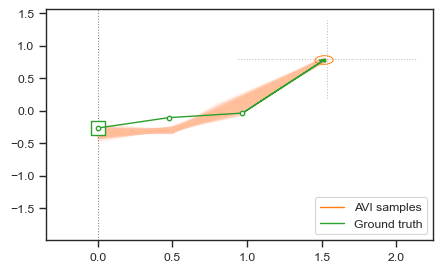

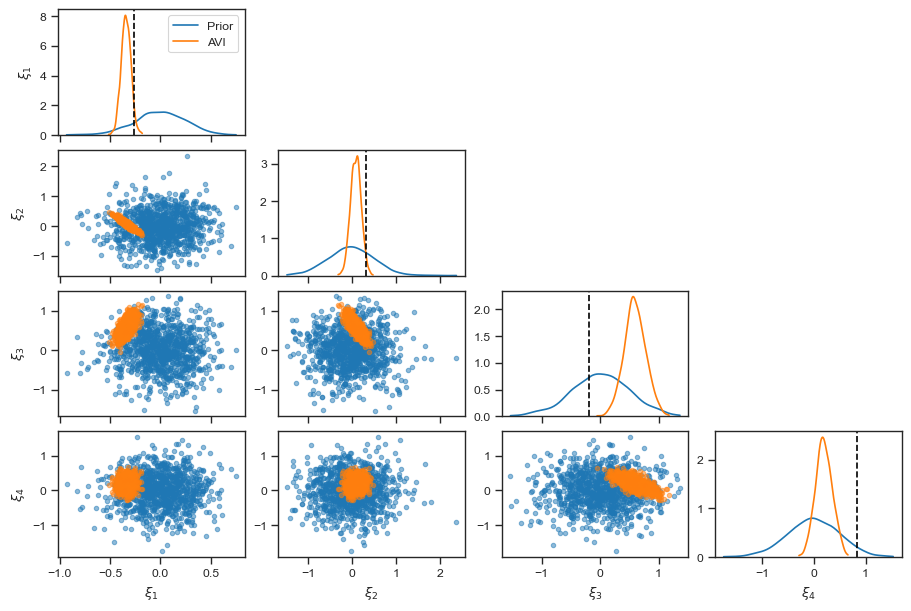

------------------------------------------------------------
Groundtruth for Case 4:
 xi_data=[0.4429261  0.8469467  0.39444223 0.43004087],
 y_data=[0.38151485 2.278995  ]
Estimated mean:
[0.6042355  0.37224448 1.2138503  0.0620077 ]
Estimated covariance matrix:
[[ 0.00276115 -0.00575572  0.00569671  0.00082421]
 [-0.00575572  0.01392949 -0.01666035  0.00200623]
 [ 0.00569671 -0.01666035  0.03139026 -0.01932308]
 [ 0.00082421  0.00200623 -0.01932308  0.02543506]]


c:\Users\motah\anaconda3\Lib\site-packages\numpy\lib\histograms.py:1065: RuntimeWarning: invalid value encountered in divide
  hist /= s
c:\Users\motah\anaconda3\Lib\site-packages\matplotlib\contour.py:1454: UserWarning: Warning: converting a masked element to nan.
  self.zmax = float(z.max())
c:\Users\motah\anaconda3\Lib\site-packages\matplotlib\contour.py:1455: UserWarning: Warning: converting a masked element to nan.
  self.zmin = float(z.min())


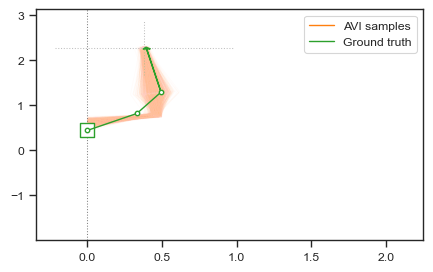

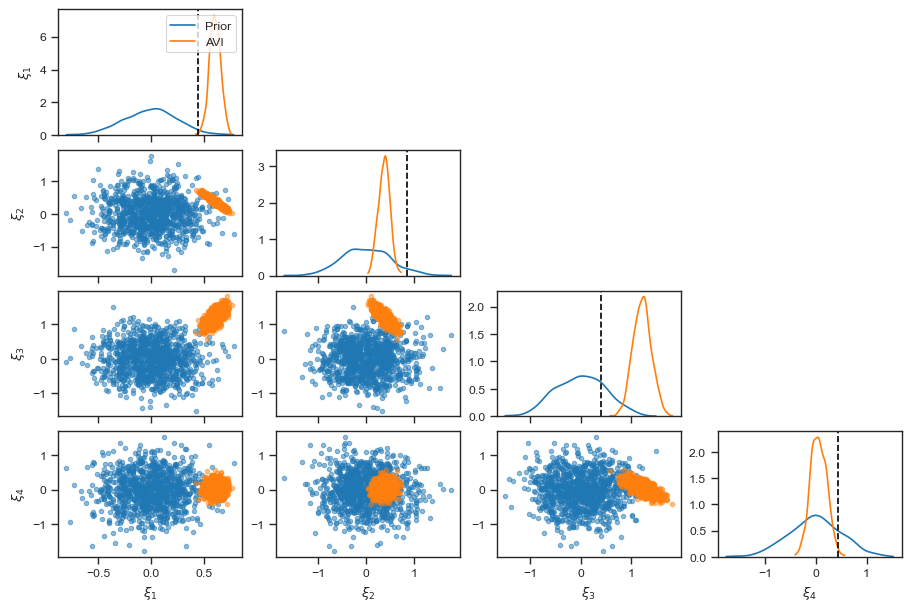

In [17]:
# Evaluation: Test trained model on multiple cases
n_samples = 1000  # Number of posterior samples to draw
postprocess_key = jr.PRNGKey(3)

for j in range(4):
    # Generate test case
    postprocess_key, data_key = jr.split(postprocess_key)
    xi_data, y_data = model.observed_data(data_key, n=1)
    
    # Infer posterior parameters from observation
    # From AVI trained inference function
    mean = model.mu(y_data[0, :])
    L_diag = model.L_diag(y_data[0, :])
    L_offdiag = model.L_offdiag(y_data[0, :])
    L = unpack_cholesky(L_diag, L_offdiag, model.xi_dim)

    # Convert to numpy for printing
    xi_data_np = np.array(xi_data[0])
    y_data_np = np.array(y_data[0])

    print('-' * 60)
    print(f"Groundtruth for Case {j+1}:\n xi_data={xi_data_np},\n y_data={y_data_np}")
    mean_np = np.array(mean)
    cov_np = np.array(L @ L.T)
    print('Estimated mean:\n' + str(mean_np))
    print('Estimated covariance matrix:\n' + str(cov_np))
    
    # Sample from AVI posterior
    postprocess_key, sample_key = jr.split(postprocess_key)
    zs = jr.normal(sample_key, (n_samples, model.xi_dim))
    xi_samples_AVI = mean[None, :] + zs @ L.T
    xi_samples_AVI_np = np.array(xi_samples_AVI)

    # Visualize reconstructed trajectories
    plot_reconstructed(xi_samples_AVI, xi_data_np[None, :], y_data_np[None, :], lens)

    # Sample from prior
    postprocess_key, prior_key = jr.split(postprocess_key)
    prior_loc = jnp.array(model.prior_xi_dist['loc'])[:model.xi_dim]
    prior_scale = jnp.array(model.prior_xi_dist['scale'])[:model.xi_dim]
    Prior_data = prior_loc[None, :] + prior_scale[None, :] * jr.normal(
        prior_key, (n_samples, model.xi_dim)
    )
    Prior_data_np = np.array(Prior_data).T
    AVI_data_np = xi_samples_AVI_np.T
    
    # Plot pair
    pair_plot(Prior_data_np, AVI_data_np, xi_data_np[None, :])


We observe that the trained AVI works well for some configurations, but for others, the posterior does not cover the true trajectory. This behavior can have several causes. First, the inverse kinematics problem is inherently non-identifiable: different joint configurations can produce the same end-effector position, and variational inference is known to be mode-seeking and to underestimate posterior variance. Second, the guide itself may be too rigid. This rigidity can come from the variational gap (the Gaussian assumption is too simple) or the amortization gap (the inference network is not expressive enough to capture the true posterior shape). As an exercise, you can increase the expressiveness of the inference network (for example by adding layers or widening them) to test whether a richer architecture leads to a better approximation and helps rule out guide rigidity as the limitation.